In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/kidneyData.csv
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (3178).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (3561).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (900).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (1148).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (268).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-S

In [2]:
from pathlib import Path

# Step 1: Point directly inside the main dataset folder
DATA_ROOT = Path("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone")

# Step 2: List all class folders
classes = [d.name for d in DATA_ROOT.iterdir() if d.is_dir()]
print("✅ Classes found:", classes)

✅ Classes found: ['CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone']


In [3]:
from pathlib import Path

# First level
DATA_ROOT = Path("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone")

# Check inside again
subfolders = [d.name for d in DATA_ROOT.iterdir() if d.is_dir()]
print("Subfolders inside:", subfolders)

Subfolders inside: ['CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone']


In [4]:
# Go one level deeper manually
DATA_ROOT = DATA_ROOT / "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

classes = [d.name for d in DATA_ROOT.iterdir() if d.is_dir()]
print("Classes found:", classes)


✅ Classes found: ['Cyst', 'Tumor', 'Stone', 'Normal']


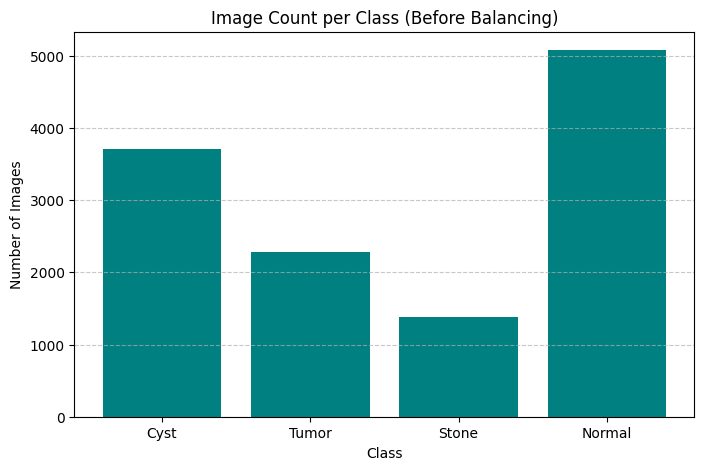

📊 Class distribution: {'Cyst': 3709, 'Tumor': 2283, 'Stone': 1377, 'Normal': 5077}


In [5]:
import matplotlib.pyplot as plt

# Count images per class
class_counts = {cls: len(list((DATA_ROOT / cls).glob("*"))) for cls in classes}

# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values(), color="teal")
plt.title("Image Count per Class (Before Balancing)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

print("Class distribution:", class_counts)

In [6]:
import os

base_path = "/kaggle/input"
print(os.listdir(base_path))  # list all datasets mounted


['ct-kidney-dataset-normal-cyst-tumor-and-stone']


In [7]:
import os
print("Classes found:", os.listdir(base_path))


Classes found: ['ct-kidney-dataset-normal-cyst-tumor-and-stone']


In [8]:
import os

# Step 1: List top-level input folders
input_folders = os.listdir('/kaggle/input')
print("Top-level input folders:", input_folders)

# Step 2: Find and inspect the kidney dataset folder (look for 'ct-kidney' or similar)
kidney_folder = None
for folder in input_folders:
    if 'kidney' in folder.lower() or 'ct-' in folder.lower():
        kidney_folder = folder
        print(f"\nFound potential dataset: {folder}")
        full_path = f"/kaggle/input/{folder}"
        inner_contents = os.listdir(full_path)
        print(f"Contents of {full_path}:", inner_contents)
        
        # Step 3: Check for class subfolders
        if 'CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone' in inner_contents:
            dataset_path = f"{full_path}/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
            classes = os.listdir(dataset_path)
            print(f"Class subfolders in {dataset_path}: {classes}")
            break
else:
    print("Kidney dataset not found—ensure it's added to your notebook via 'Add Data'!")

Top-level input folders: ['ct-kidney-dataset-normal-cyst-tumor-and-stone']

Found potential dataset: ct-kidney-dataset-normal-cyst-tumor-and-stone
Contents of /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone: ['kidneyData.csv', 'CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone']
Class subfolders in /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone: ['CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone']


In [9]:
import os

data_path = "/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
print("Inside dataset folder:", os.listdir(data_path))


Inside dataset folder: ['CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone']


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
import os

# Keras/TensorFlow imports
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

2025-11-19 04:29:01.868196: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763526542.080504      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763526542.140738      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [11]:
# List all files in the input directory
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames[:10]:  # Limit to first 10 for brevity
        print(os.path.join(dirname, filename))
print("... (truncated for brevity)")

/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/kidneyData.csv
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (3178).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (3561).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (900).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (1148).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (268).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-S

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
import os

# Keras/TensorFlow imports
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [13]:
# List all files in the input directory
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames[:10]:  # Limit to first 10 for brevity
        print(os.path.join(dirname, filename))
print("... (truncated for brevity)")

/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/kidneyData.csv
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (3178).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (3561).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (900).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (1148).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (268).jpg
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-S

Compute Class Weights

In [46]:
import os

base = "/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone"

print("Level 1:", base)
print(os.listdir(base))

print("\nLevel 2:")
level2 = os.path.join(base, "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone")
print(level2)
print(os.listdir(level2))

print("\nLevel 3 (inside Level 2):")
level3 = os.path.join(level2, "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone")
if os.path.exists(level3):
    print(level3)
    print(os.listdir(level3))
else:
    print("No second nested folder with same name.")


Level 1: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone
['kidneyData.csv', 'CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone']

Level 2:
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone
['CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone']

Level 3 (inside Level 2):
/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone
['Cyst', 'Tumor', 'Stone', 'Normal']


In [47]:
data_dir = "/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"


In [49]:
val_batches = tf.data.experimental.cardinality(val_ds_raw)
test_ds = val_ds_raw.take(val_batches // 2)
val_ds  = val_ds_raw.skip(val_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds_raw.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

class_names = train_ds_raw.class_names
num_classes = len(class_names)
print("num_classes:", num_classes)


num_classes: 4


In [50]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
x = tf.keras.layers.Dropout(0.3, name="dropout")(x)

outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="predictions")(x)

resnet_model = tf.keras.Model(inputs, outputs, name="ResNet50_kidney")

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [51]:
history_1 = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint_cb, earlystop_cb]
)


Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.7716 - loss: 0.5832
Epoch 1: val_accuracy improved from 0.00000 to 0.95004, saving model to resnet50_best.keras
312/312 ━━━━━━━━━━━━━━━━━━━━ 102s 226ms/step - accuracy: 0.7719 - loss: 0.5823 - val_accuracy: 0.9500 - val_loss: 0.1352
Epoch 2/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9725 - loss: 0.0803
Epoch 2: val_accuracy improved from 0.95004 to 0.95407, saving model to resnet50_best.keras
312/312 ━━━━━━━━━━━━━━━━━━━━ 78s 207ms/step - accuracy: 0.9725 - loss: 0.0802 - val_accuracy: 0.9541 - val_loss: 0.1431
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9809 - loss: 0.0549
Epoch 3: val_accuracy improved from 0.95407 to 0.97099, saving model to resnet50_best.keras
312/312 ━━━━━━━━━━━━━━━━━━━━ 78s 208ms/step - accuracy: 0.9809 - loss: 0.0549 - val_accuracy: 0.9710 - val_loss: 0.0756
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9881 - loss: 0.0342
Epoch 4: va

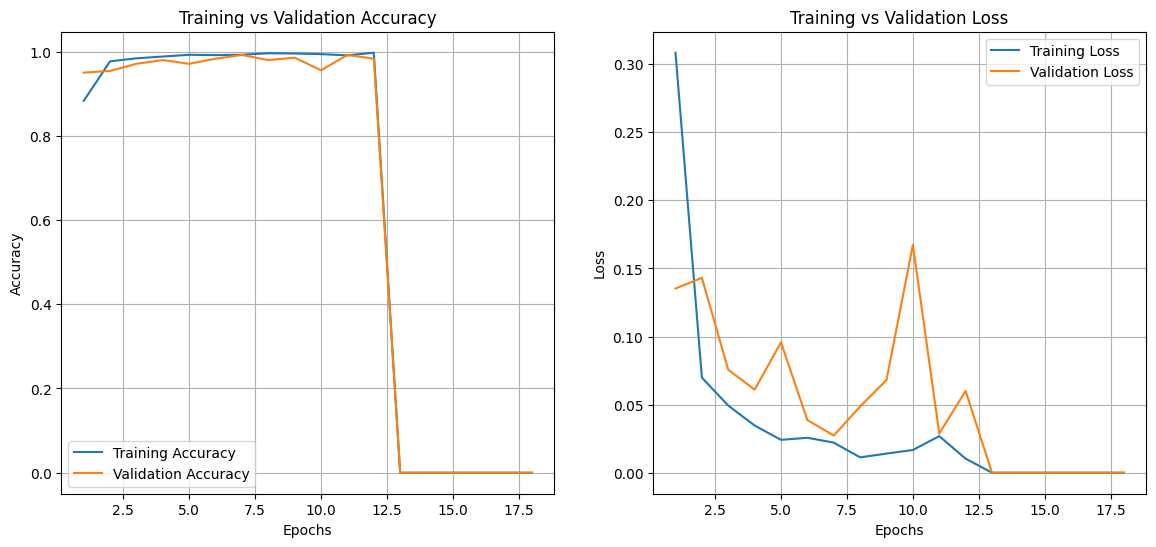

In [54]:
import matplotlib.pyplot as plt

# If you have two histories (before & after fine-tuning):
# Combine them for one continuous graph
def merge_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history.get('accuracy', [])
    val_acc = h1.history['val_accuracy'] + h2.history.get('val_accuracy', [])
    loss = h1.history['loss'] + h2.history.get('loss', [])
    val_loss = h1.history['val_loss'] + h2.history.get('val_loss', [])
    return acc, val_acc, loss, val_loss

# If only one history exists, use this
try:
    acc, val_acc, loss, val_loss = merge_history(history_1, history_2)
except:
    acc = history_1.history['accuracy']
    val_acc = history_1.history['val_accuracy']
    loss = history_1.history['loss']
    val_loss = history_1.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()


In [55]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = resnet_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [56]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Confusion Matrix:
 [[368   0   0   0]
 [  0 492   0   1]
 [  2   0 142   0]
 [  1   0   0 242]]

Classification Report:

              precision    recall  f1-score   support

        Cyst       0.99      1.00      1.00       368
      Normal       1.00      1.00      1.00       493
       Stone       1.00      0.99      0.99       144
       Tumor       1.00      1.00      1.00       243

    accuracy                           1.00      1248
   macro avg       1.00      0.99      1.00      1248
weighted avg       1.00      1.00      1.00      1248



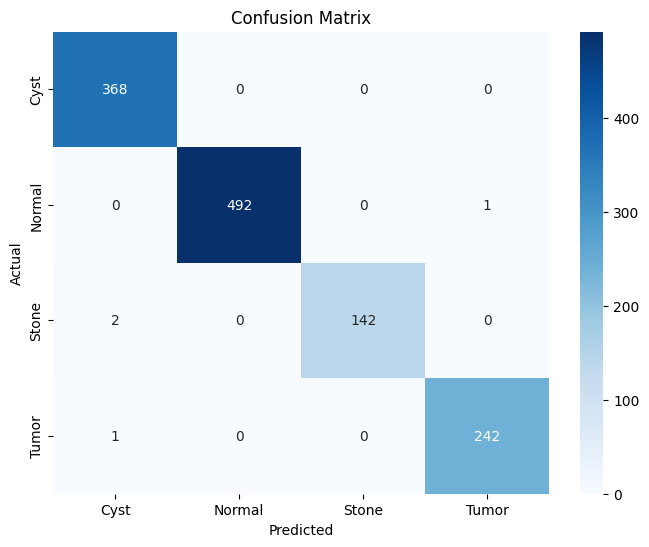

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
from collections import Counter
import numpy as np

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 16  # Reduce to 8 if OOM

# FIXED BASE_PATH: Triple-nested to class subfolders
BASE_PATH = "/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

# Verify path and contents
if not os.path.exists(BASE_PATH):
    raise FileNotFoundError(f"BASE_PATH not found: {BASE_PATH}")
print("Contents of BASE_PATH (classes):", os.listdir(BASE_PATH))  # Expected: ['Cyst', 'Normal', 'Stone', 'Tumor']

# Train generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    BASE_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

# Validation generator
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_gen = val_datagen.flow_from_directory(
    BASE_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

print("Classes:", train_gen.class_indices)
print(f"Train samples: {train_gen.samples}, Val samples: {val_gen.samples}")

# Class distribution
train_labels = train_gen.classes
train_class_counts = Counter(train_labels)
class_names = list(train_gen.class_indices.keys())
print("\nTrain distribution:")
for i, name in enumerate(class_names):
    count = train_class_counts[i]
    print(f"{name}: {count} ({count / train_gen.samples * 100:.1f}%)")

val_labels = val_gen.classes
val_class_counts = Counter(val_labels)
print("\nVal distribution:")
for i, name in enumerate(class_names):
    count = val_class_counts[i]
    print(f"{name}: {count} ({count / val_gen.samples * 100:.1f}%)")

Contents of BASE_PATH (classes): ['Cyst', 'Tumor', 'Stone', 'Normal']
Found 9959 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Classes: {'Cyst': 0, 'Normal': 1, 'Stone': 2, 'Tumor': 3}
Train samples: 9959, Val samples: 2487

Train distribution:
Cyst: 2968 (29.8%)
Normal: 4062 (40.8%)
Stone: 1102 (11.1%)
Tumor: 1827 (18.3%)

Val distribution:
Cyst: 741 (29.8%)
Normal: 1015 (40.8%)
Stone: 275 (11.1%)
Tumor: 456 (18.3%)


In [15]:
from sklearn.utils.class_weight import compute_class_weight

unique_classes = np.unique(train_labels)
class_weights = compute_class_weight('balanced', classes=unique_classes, y=train_labels)
class_weight_dict = dict(zip(unique_classes, class_weights))
print("\nClass weights:")
for i, weight in enumerate(class_weights):
    print(f"{class_names[i]}: {weight:.4f}")


Class weights:
Cyst: 0.8389
Normal: 0.6129
Stone: 2.2593
Tumor: 1.3628


Build and Compile ResNet50 Model

In [16]:
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Class distribution
train_labels = train_gen.classes
class_counts = Counter(train_labels)
class_names = list(train_gen.class_indices.keys())
print("\nTrain distribution:")
for i, name in enumerate(class_names):
    count = class_counts[i]
    print(f"{name}: {count} ({count / train_gen.samples * 100:.1f}%)")

# Class weights for balancing
unique_classes = np.unique(train_labels)
class_weights = compute_class_weight('balanced', classes=unique_classes, y=train_labels)
class_weight_dict = dict(zip(unique_classes, class_weights))
print("\nClass weights:")
for i, weight in enumerate(class_weights):
    print(f"{class_names[i]}: {weight:.4f}")


Train distribution:
Cyst: 2968 (29.8%)
Normal: 4062 (40.8%)
Stone: 1102 (11.1%)
Tumor: 1827 (18.3%)

Class weights:
Cyst: 0.8389
Normal: 0.6129
Stone: 2.2593
Tumor: 1.3628


In [17]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Load pre-trained ResNet50 (freeze base layers initially)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False  # Freeze to retain pre-trained features

# Add custom head for 4 classes
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)  # Regularization to prevent overfitting
predictions = Dense(len(class_names), activation='softmax')(x)

# Full model
resnet_model = Model(inputs=base_model.input, outputs=predictions)

# Compile
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-4),  # Low LR for transfer learning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary (optional: shows ~25M params, trainable ~0.7M)
resnet_model.summary()

I0000 00:00:1763526559.196088      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763526559.196916      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Set Up Callbacks

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1, min_lr=1e-7),
    ModelCheckpoint('best_resnet_kidney.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

Train the Model

In [19]:
# Define class_weight_dict from your output
class_weight_dict = {0: 0.8389, 1: 0.6129, 2: 2.2593, 3: 1.3628}  # Cyst:0, Normal:1, Stone:2, Tumor:3

# Train
history = resnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1763526574.523845     116 service.cc:148] XLA service 0x7e1c34003720 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763526574.524529     116 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1763526574.524550     116 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1763526576.093418     116 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/623 ━━━━━━━━━━━━━━━━━━━━ 2:58:09 17s/step - accuracy: 0.2500 - loss: 1.4942

I0000 00:00:1763526580.610278     116 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.2744 - loss: 1.5102
Epoch 1: val_loss improved from inf to 1.36661, saving model to best_resnet_kidney.keras
623/623 ━━━━━━━━━━━━━━━━━━━━ 276s 416ms/step - accuracy: 0.2744 - loss: 1.5101 - val_accuracy: 0.2131 - val_loss: 1.3666 - learning_rate: 1.0000e-04
Epoch 2/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.4122 - loss: 1.3132
Epoch 2: val_loss improved from 1.36661 to 1.28384, saving model to best_resnet_kidney.keras
623/623 ━━━━━━━━━━━━━━━━━━━━ 160s 256ms/step - accuracy: 0.4122 - loss: 1.3132 - val_accuracy: 0.4568 - val_loss: 1.2838 - learning_rate: 1.0000e-04
Epoch 3/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.4645 - loss: 1.2762
Epoch 3: val_loss improved from 1.28384 to 1.26295, saving model to best_resnet_kidney.keras
623/623 ━━━━━━━━━━━━━━━━━━━━ 160s 257ms/step - accuracy: 0.4646 - loss: 1.2761 - val_accuracy: 0.4495 - val_loss: 1.2629 - learning_rate: 1.0000e-04
Epoch 4/20
623/623 ━━━━━━

In [20]:
# Define class_weight_dict from your output
class_weight_dict = {0: 0.8389, 1: 0.6129, 2: 2.2593, 3: 1.3628}  # Cyst:0, Normal:1, Stone:2, Tumor:3

# Train
history = resnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.5998 - loss: 1.0632
Epoch 1: val_loss did not improve from 1.22452
623/623 ━━━━━━━━━━━━━━━━━━━━ 153s 245ms/step - accuracy: 0.5998 - loss: 1.0632 - val_accuracy: 0.4986 - val_loss: 1.2470 - learning_rate: 2.0000e-05
Epoch 2/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.6018 - loss: 1.0478
Epoch 2: val_loss did not improve from 1.22452
623/623 ━━━━━━━━━━━━━━━━━━━━ 150s 240ms/step - accuracy: 0.6018 - loss: 1.0478 - val_accuracy: 0.5074 - val_loss: 1.2414 - learning_rate: 2.0000e-05
Epoch 3/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.6053 - loss: 1.0437
Epoch 3: val_loss did not improve from 1.22452
623/623 ━━━━━━━━━━━━━━━━━━━━ 144s 231ms/step - accuracy: 0.6053 - loss: 1.0437 - val_accuracy: 0.4990 - val_loss: 1.2392 - learning_rate: 2.0000e-05
Epoch 4/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.6091 - loss: 1.0536
Epoch 4: val_loss did not improve from 1.22452
623/623 ━━━━━

Plot Training Curves

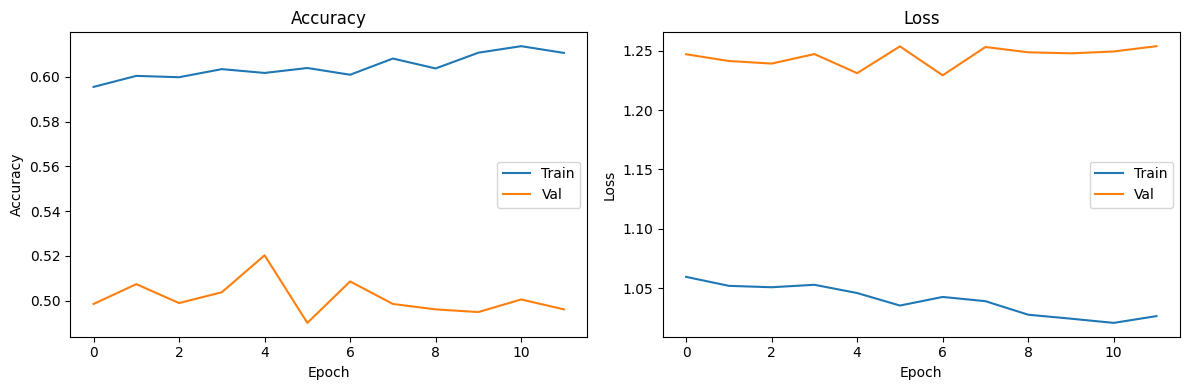

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Evaluate and Save

156/156 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.5532 - loss: 1.0995
Val Accuracy: 0.5086, Val Loss: 1.2293
156/156 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step

Classification Report:
              precision    recall  f1-score   support

        Cyst       0.44      0.55      0.49       741
      Normal       0.75      0.57      0.65      1015
       Stone       0.41      0.30      0.35       275
       Tumor       0.34      0.43      0.38       456

    accuracy                           0.51      2487
   macro avg       0.48      0.46      0.47      2487
weighted avg       0.54      0.51      0.52      2487



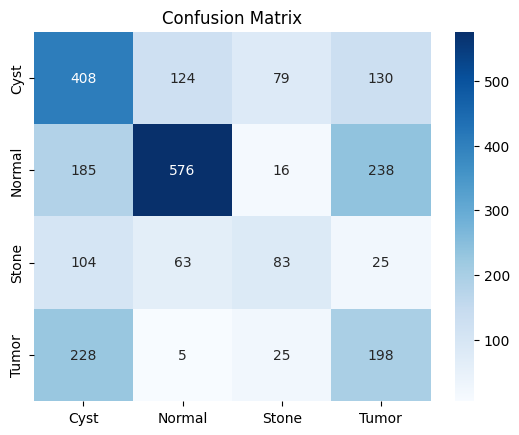

Saved!


In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

val_loss, val_acc = resnet_model.evaluate(val_gen)
print(f"Val Accuracy: {val_acc:.4f}, Val Loss: {val_loss:.4f}")

y_pred = resnet_model.predict(val_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.show()

resnet_model.save('kidney_resnet_final.keras')
print("Saved!")

In [23]:
# Save the model
resnet_model.save('kidney_resnet_balanced.keras')
print("Model saved as 'kidney_resnet_balanced.keras'")

Model saved as 'kidney_resnet_balanced.keras'


In [24]:
# Step 1: Import all required libraries

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import numpy as np

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.18.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [25]:
# Step 2: Dataset path and basic settings

# CHANGE this if your path is different
data_dir = "/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

IMG_SIZE = 224      # ResNet50 standard input size
BATCH_SIZE = 32
SEED = 42
EPOCHS = 20


In [26]:
# Step 3: Create train / validation / test datasets

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,      # 80% train, 20% val
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# Split val_ds into val + test (50-50 of that 20%)
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)


Found 12446 files belonging to 1 classes.
Using 9957 files for training.
Found 12446 files belonging to 1 classes.
Using 2489 files for validation.
Classes: ['CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone']
Number of classes: 1


In [28]:
# Step 4: Performance optimizations

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)


In [29]:
# Step 5: Data augmentation (applied on-the-fly during training)

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ],
    name="data_augmentation"
)


In [30]:
# Step 6: Build ResNet50-based model (feature extractor + custom head)

# 6.1 Load base ResNet50 (pretrained on ImageNet)
base_model = ResNet50(
    include_top=False,             # remove original classifier
    weights="imagenet",            # use pretrained weights
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# 6.2 Freeze base model (only train our classifier first)
base_model.trainable = False

# 6.3 Build our full model
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")

# Apply data augmentation
x = data_augmentation(inputs)

# Apply ResNet50 preprocessing
x = preprocess_input(x)

# Pass through ResNet50
x = base_model(x, training=False)

# Global average pooling to reduce feature map to vector
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)

# Dropout to reduce overfitting
x = layers.Dropout(0.3, name="dropout")(x)

# Final dense layer for classification
outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

# Create model
resnet_model = models.Model(inputs, outputs, name="ResNet50_kidney")

# Show model summary
resnet_model.summary()


Model: "ResNet50_kidney"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [31]:
# Step 7: Compile the model (Phase 1: only top layers trainable)

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [32]:
# Step 8: Define callbacks

checkpoint_path = "resnet50_best.keras"   # best model will be saved here

checkpoint_cb = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=5,             # stop if val_loss not improving for 5 epochs
    restore_best_weights=True,
    verbose=1
)


In [41]:
data_dir = "/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"


In [48]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

print("Class names:", train_ds_raw.class_names)
print("Number of classes:", len(train_ds_raw.class_names))


Found 12446 files belonging to 4 classes.
Using 9957 files for training.
Found 12446 files belonging to 4 classes.
Using 2489 files for validation.
Class names: ['Cyst', 'Normal', 'Stone', 'Tumor']
Number of classes: 4


In [ ]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
x = tf.keras.layers.Dropout(0.3, name="dropout")(x)

outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="predictions")(x)

resnet_model = tf.keras.Model(inputs, outputs, name="ResNet50_kidney")

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_1 = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint_cb, earlystop_cb]
)


In [42]:
import os

print(os.listdir("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone"))
print(os.listdir(data_dir))  # should show: ['Cyst', 'Normal', 'Stone', 'Tumor'] or similar


['kidneyData.csv', 'CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone']
['CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone']


In [43]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)


Found 12446 files belonging to 1 classes.
Using 9957 files for training.
Found 12446 files belonging to 1 classes.
Using 2489 files for validation.


In [45]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

print("Class names:", train_ds_raw.class_names)
print("Number of classes:", len(train_ds_raw.class_names))


Found 12446 files belonging to 1 classes.
Using 9957 files for training.
Found 12446 files belonging to 1 classes.
Using 2489 files for validation.
Class names: ['CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone']
Number of classes: 1


In [44]:
print("Class names:", train_ds_raw.class_names)
print("Number of classes:", len(train_ds_raw.class_names))


Class names: ['CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone']
Number of classes: 1


In [39]:
val_batches = tf.data.experimental.cardinality(val_ds_raw)
test_ds = val_ds_raw.take(val_batches // 2)
val_ds = val_ds_raw.skip(val_batches // 2)


In [40]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds_raw.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)
